В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдені параметри моделі близькими до ваших найкращих припущень?

In [264]:
!pip install scikit-learn --quiet

In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

In [266]:
medical_df = pd.read_csv('medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']
smoker_df = medical_df[medical_df.smoker == 'yes']

In [267]:
X = non_smoker_df['age']
y = non_smoker_df['charges']

In [268]:
X.describe()

,age
count,1064.000000
mean,39.385338
std,14.083410
min,18.000000
25%,26.750000
50%,40.000000
75%,52.000000
max,64.000000


In [269]:
y.describe()

,charges
count,1064.000000
mean,8434.268298
std,5993.781819
min,1121.873900
25%,3986.438700
50%,7345.405300
75%,11362.887050
max,36910.608030


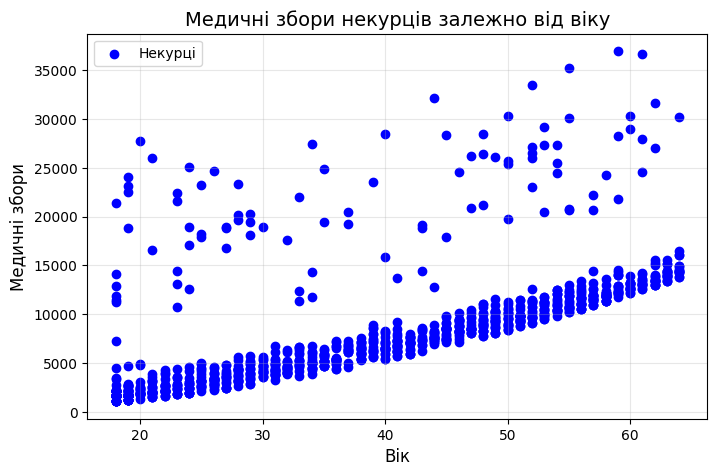

In [270]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Некурці')
plt.xlabel('Вік', fontsize=12)
plt.ylabel('Медичні збори', fontsize=12)
plt.title('Медичні збори некурців залежно від віку', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Спостереження:**

На графіку чітко видно два окремі кластери точок:
- Нижній кластер (до близько 16 000 медичних зборів)
- Верхній кластер (приблизно 15 000 – 37 000)

### МНК-метод

In [271]:
X = np.array(non_smoker_df['age'])
y = np.array(non_smoker_df['charges'])

In [272]:
X, y

(array([18, 28, 33, ..., 18, 18, 21]),
 array([ 1725.5523 ,  4449.462  , 21984.47061, ...,  2205.9808 ,
         1629.8335 ,  2007.945  ]))

In [273]:
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X.reshape(-1, 1)]
X[:3], X_with_intercept[:3]

(array([18, 28, 33]),
 array([[ 1., 18.],
        [ 1., 28.],
        [ 1., 33.]]))

In [274]:
def normal_equations(X, y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [275]:
MNK_coefs = normal_equations(X_with_intercept, y)

In [276]:
MNK_coefs

array([-2091.42055657,   267.24891283])

In [277]:
np.dot(X_with_intercept[0], MNK_coefs)

np.float64(2719.059874396516)

In [278]:
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)

In [279]:
predictions_MNK[:3], y[:3]

(array([2719.0598744 , 5391.54900271, 6727.79356686]),
 array([ 1725.5523 ,  4449.462  , 21984.47061]))

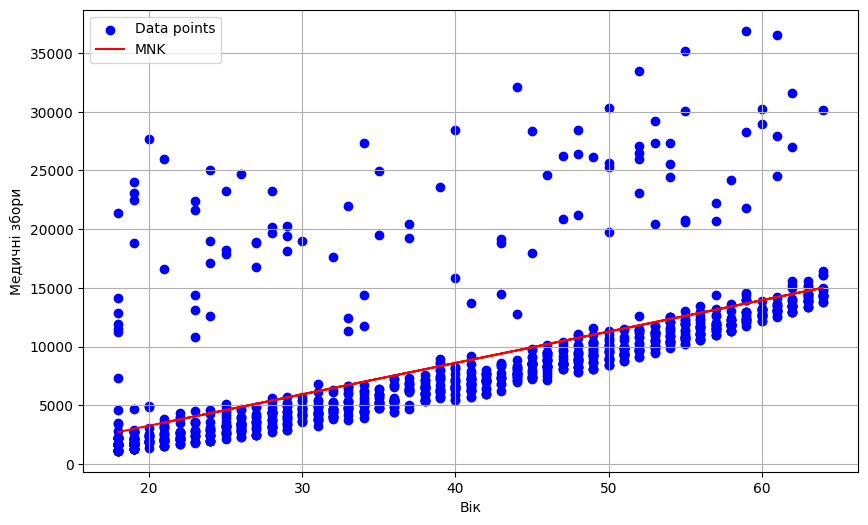

In [280]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.xlabel('Вік')
plt.ylabel('Медичні збори')
plt.legend()
plt.grid(True)
plt.show()

In [281]:
r2 = r2_score(y, predictions_MNK)
rmse = root_mean_squared_error(y, predictions_MNK)
mae = mean_absolute_error(y, predictions_MNK)

print(f"R² score: {r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

R² score: 0.39
Root Mean Squared Error: 4662.51
Mean Absolute Error: 2580.52


In [282]:
np.mean(y), np.std(y), np.min(y)

(np.float64(8434.268297856204),
 np.float64(5990.9645302876115),
 np.float64(1121.8739))

### Full-Batch градієнтного спуску

In [283]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 1] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 1])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [284]:
lr_01_m, lr_01_b, errors_01 = full_batch_gradient_descent(
    X_with_intercept, y, lr=0.0001, epochs=2000)

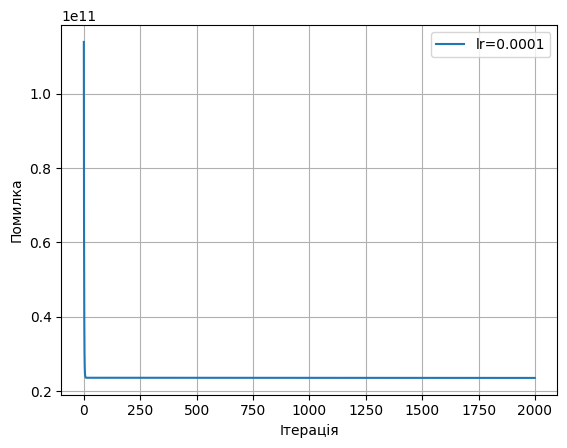

In [285]:
plt.plot(errors_01, label='lr=0.0001')
plt.xlabel('Ітерація')
plt.ylabel('Помилка')
plt.legend()
plt.grid(True)
plt.show()

In [286]:
lr_02_m, lr_02_b, errors_02 = full_batch_gradient_descent(
    X_with_intercept, y, lr=0.00001, epochs=2000)

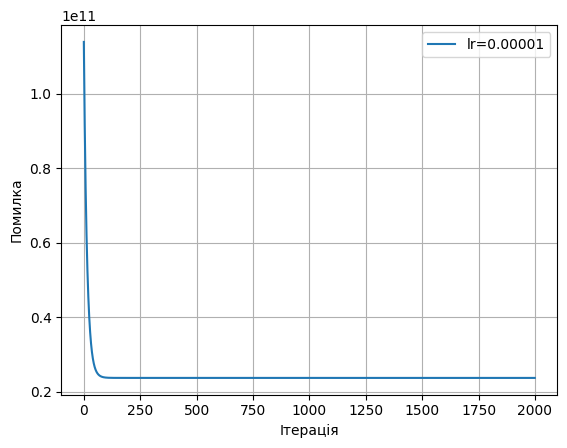

In [287]:
plt.plot(errors_02, label='lr=0.00001')
plt.xlabel('Ітерація')
plt.ylabel('Помилка')
plt.legend()
plt.grid(True)
plt.show()

In [288]:
lr_03_m, lr_03_b, errors_03 = full_batch_gradient_descent(
    X_with_intercept, y, lr=0.000001, epochs=2000)

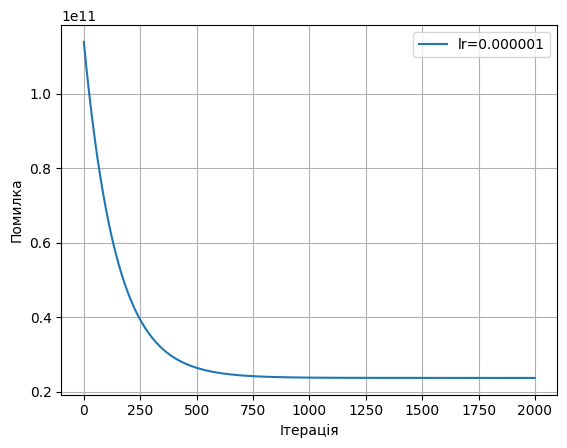

In [289]:
plt.plot(errors_03, label='lr=0.000001')
plt.xlabel('Ітерація')
plt.ylabel('Помилка')
plt.legend()
plt.grid(True)
plt.show()

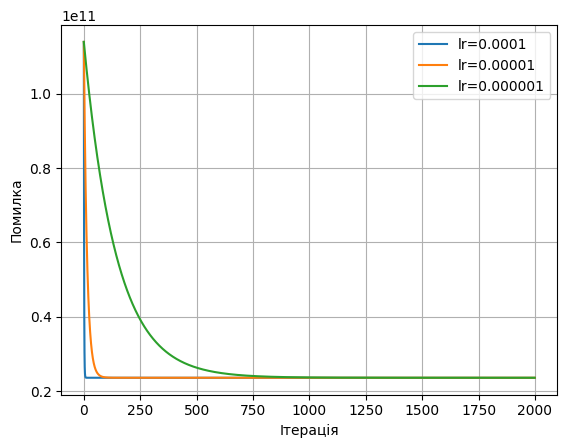

In [290]:
plt.plot(errors_01, label='lr=0.0001')
plt.plot(errors_02, label='lr=0.00001')
plt.plot(errors_03, label='lr=0.000001')
plt.xlabel('Ітерація')
plt.ylabel('Помилка')
plt.legend()
plt.grid(True)
plt.show()

In [291]:
m, b, errors = full_batch_gradient_descent(
    X_with_intercept, y, lr=0.0001, epochs=2000)

predictions_fbgd = m * X_with_intercept[:, 1] + b

In [292]:
m, b

(np.float64(222.1377104665648), np.float64(-87.86619661490121))

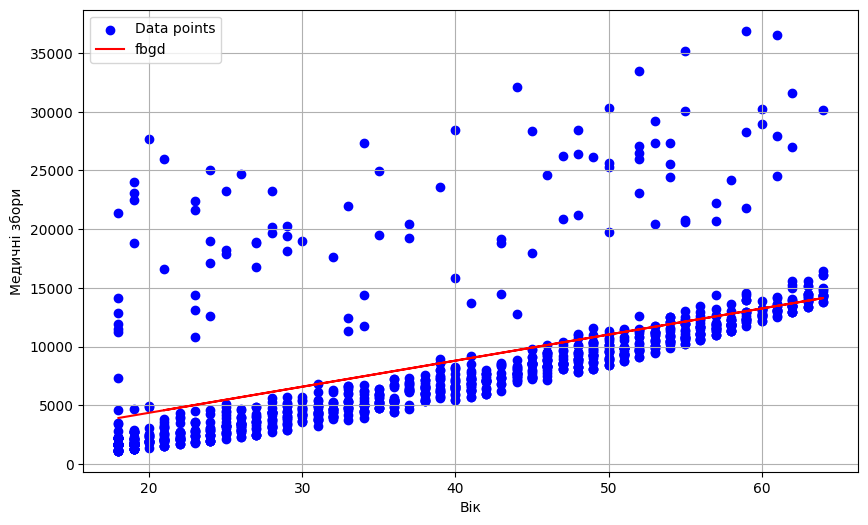

In [293]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_fbgd, color='red', label='fbgd')
plt.xlabel('Вік')
plt.ylabel('Медичні збори')
plt.legend()
plt.grid(True)
plt.show()

In [294]:
r2 = r2_score(y, predictions_fbgd)
rmse = root_mean_squared_error(y, predictions_fbgd)
mae = mean_absolute_error(y, predictions_fbgd)

print(f"R² score: {r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

R² score: 0.38
Root Mean Squared Error: 4711.02
Mean Absolute Error: 2797.94


### Висновок:
Було протестовано три значення learning rate: 0.0001, 0.00001 та 0.000001.

- `lr = 0.0001` - найкращий варіант: помилка швидко спадає і стабілізується вже в перших ітераціях. Модель збігається до оптимального рішення за 2000 епох.
- `lr = 0.0000`1 - помилка спадає трохи повільніше, збіжність повна після 2000 ітерацій, проте швидкість спуску трохи менша, ніж при `lr = 0.0001`
- `lr = 0.000001` - в цьому варіанті збіжність настає також за 2000 епох, проте на графіку чітко видно, що за швидкістю стабілізації програє першим двом показникам.

Загалом всі три варіанти прийшли до збіжності за 2000 епох, проте варіант `lr = 0.0001` був найкращим, оскільки найшвидший і при цьому не мав розходження.


### scikit-learn

In [295]:
lin_reg = LinearRegression()

In [296]:
X_sklearn = X.reshape(-1, 1)

In [297]:
X_sklearn

array([[18],
       [28],
       [33],
       ...,
       [18],
       [18],
       [21]])

In [298]:
lin_reg

LinearRegression()

In [299]:
lin_reg.fit(X_sklearn, y)

LinearRegression()

In [300]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), np.float64(-2091.4205565650864))

In [301]:
predictions_sklearn = lin_reg.predict(X_sklearn)

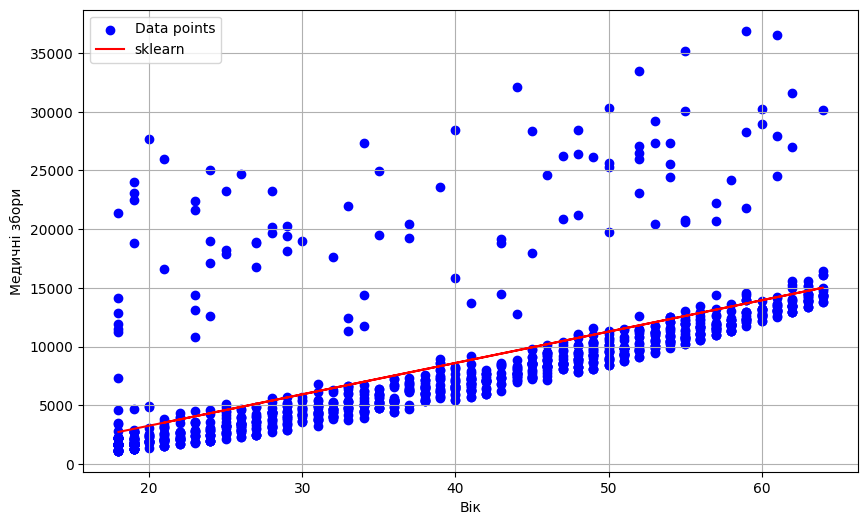

In [302]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_sklearn, color='red', label='sklearn')
plt.xlabel('Вік')
plt.ylabel('Медичні збори')
plt.legend()
plt.grid(True)
plt.show()

In [303]:
r2 = r2_score(y, predictions_sklearn)
rmse = root_mean_squared_error(y, predictions_sklearn)
mae = mean_absolute_error(y, predictions_sklearn)

print(f"R² score: {r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

R² score: 0.39
Root Mean Squared Error: 4662.51
Mean Absolute Error: 2580.52


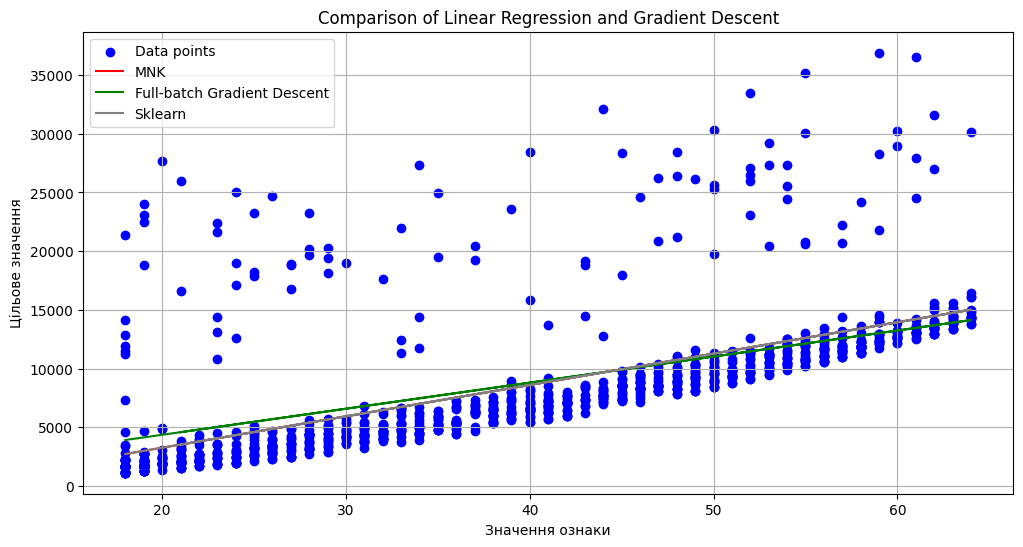

In [304]:
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.plot(X, predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(X, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()


### **Висновок:**

- Оскільки sklear під капотом реалізує МНК, то їх лінії (червона та сіра) на графіку накладаються одна на одну та передбачення моделей збігаються.
- FBGD з правильно підібраним learning rate наближається до того схожого передбачення, проте дає трохи гірший результат в порівнянні з МНК та sklear.




 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [305]:
X_s = smoker_df['age']
y_s = smoker_df['charges']

In [306]:
lin_reg_s = LinearRegression()

In [307]:
X_s_sklearn = X_s.to_frame()

In [308]:
lin_reg_s

LinearRegression()

In [309]:
lin_reg_s.fit(X_s_sklearn, y_s)

LinearRegression()

In [310]:
lin_reg_s.coef_, lin_reg_s.intercept_

(array([305.23760211]), np.float64(20294.128126915966))

In [311]:
predictions_s_sklearn = lin_reg_s.predict(X_s_sklearn)

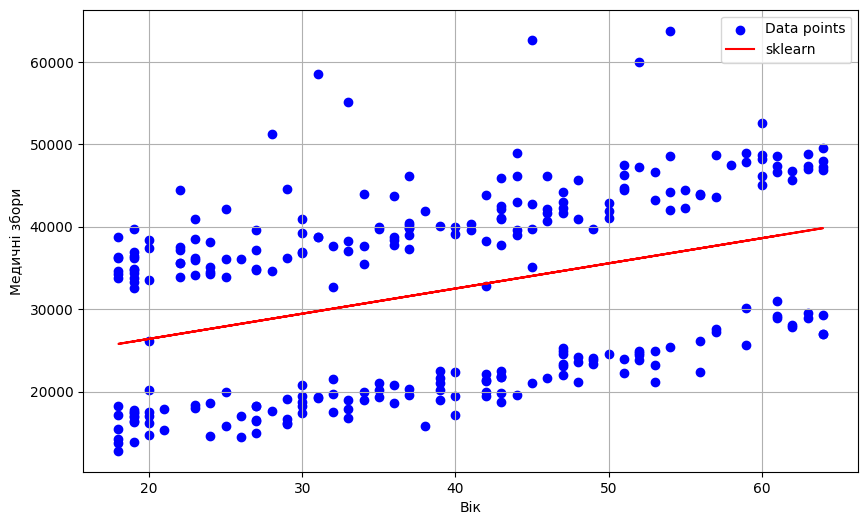

In [312]:
plt.figure(figsize=(10, 6))
plt.scatter(X_s, y_s, color='blue', label='Data points')
plt.plot(X_s, predictions_s_sklearn, color='red', label='sklearn')
plt.xlabel('Вік')
plt.ylabel('Медичні збори')
plt.legend()
plt.grid(True)
plt.show()

In [313]:
r2 = r2_score(y_s, predictions_s_sklearn)
rmse = root_mean_squared_error(y_s, predictions_s_sklearn)
mae = mean_absolute_error(y_s, predictions_s_sklearn)

print(f"R² score: {r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

R² score: 0.14
Root Mean Squared Error: 10711.00
Mean Absolute Error: 10097.80


In [314]:
np.mean(y_s), np.std(y_s), np.min(y_s)

(np.float64(32050.23183153284), 11520.466706529429, 12829.4551)

### **Висновок:**
- На графіку залежності медичних зборів від віку для курців чітко видно два кластери медичних зборів різних за величиною, з цього робимо висновок, що окрім віку та статусу курця/некурця, на розмір медичних зборів також впливає іннший показник.
- Значення R² (0.14) є дуже низьким - модель переоцінює витрати для першого кластеру та недооцінює для другого.
- RMSE близький середнього значення зборів.

Тому цю модель не варто використовувати у компанії.
